# SVD y LSA con reviews de Counter-Strike en Steam

En este notebook trabajamos con reseñas del juego Counter-Strike obtenidas desde un dataset público de Kaggle.

Como todas las reseñas pertenecen al mismo juego, cada documento del corpus será construido agrupando varias reviews consecutivas. Cada documento corresponde a un bloque de 80 reseñas concatenadas.

Luego construiremos matrices documento-palabra y término-documento, aplicaremos SVD y analizaremos representaciones de baja dimensión.

Vamos a construir una matriz término-documento, aplicar SVD y usarla para hacer análisis semántico latente, o LSA, sobre un corpus real.

In [1]:
pip install numpy pandas matplotlib scikit-learn

dataset de: https://www.kaggle.com/datasets/andrewmvd/steam-reviews/data

## Preparación del archivo de datos

Esta sección solo debe ejecutarse si todavía no existe el archivo "counter_strike_solo.csv". Si el archivo ya está disponible, se puede comenzar directamente desde P1.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving counterstrike_reviews.csv to counterstrike_reviews.csv


In [6]:
import pandas as pd

archivo = "counterstrike_reviews.csv"

df = pd.read_csv(archivo)

df_cs = df[df["app_name"] == "Counter-Strike"].copy()

df_cs.shape

(12353, 5)

In [7]:
df_cs["app_name"].value_counts()

,count
app_name,
Counter-Strike,12353


In [8]:
df_cs.to_csv("counter_strike_solo.csv", index=False)

In [9]:
files.download("counter_strike_solo.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Imports

import math
from pathlib import Path
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_extraction import text
from sklearn.metrics.pairwise import cosine_similarity


OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## P1. Elección y descripción del corpus

### P1.1 Motivación y preguntas

En esta parte usamos LSA para analizar reseñas de Counter-Strike en Steam. Queremos estudiar si la SVD permite encontrar temas latentes dentro de las opiniones de los usuarios.

Buscamos responder las siguientes preguntas:

1. ¿Cuántas componentes parecen concentrar una parte importante de la estructura del corpus?
2. ¿Qué temas semánticos aparecen en las componentes principales?
3. ¿Qué bloques de reseñas quedan cercanos en baja dimensión?
4. ¿Qué términos aparecen relacionados en la representación reducida?


### P1.2 Cargar datos

En esta parte cargamos las reseñas de Counter-Strike obtenidas desde un dataset público de Kaggle sobre reviews de Steam.

El archivo original era demasiado grande para trabajarlo directamente, por lo que primero se filtraron solo las filas correspondientes al juego "Counter-Strike". El archivo resultante se llama "counter_strike_solo.csv".

A partir de estas reseñas construiremos un corpus donde cada documento será un bloque de varias reviews concatenadas. Esto permite tener una cantidad suficiente de documentos para aplicar LSA.

In [11]:
def encontrar_csv(inicio=Path.cwd()):
    inicio = inicio.resolve()

    posibles_nombres = [
        "counter_strike_solo.csv",
        "counterstrike_reviews.csv",
    ]

    posibles_carpetas = [
        inicio,
        Path("/content"),
        inicio / "data" / "raw",
        inicio.parent / "data" / "raw",
    ]

    for carpeta in posibles_carpetas:
        for nombre in posibles_nombres:
            candidato = carpeta / nombre
            if candidato.exists():
                return candidato

    raise FileNotFoundError(
        "No encontré el archivo counter_strike_solo.csv. "
        "Súbelo a Colab o guárdalo en data/raw/."
    )


def limpiar_review(texto):
    texto = str(texto)
    texto = re.sub(r"<.*?>", " ", texto)              # elimina HTML simple
    texto = re.sub(r"http\S+|www\S+", " ", texto)     # elimina links
    texto = re.sub(r"\s+", " ", texto)                # normaliza espacios
    return texto.strip()


CSV_PATH = encontrar_csv()
reviews = pd.read_csv(CSV_PATH)

# Detectamos la columna de texto
TEXT_COLUMN_CANDIDATES = ["review", "content", "text", "review_text", "sentence"]
columnas_normalizadas = {col.lower(): col for col in reviews.columns}

for candidata in TEXT_COLUMN_CANDIDATES:
    if candidata in columnas_normalizadas:
        TEXT_COLUMN = columnas_normalizadas[candidata]
        break
else:
    raise ValueError(f"No encontré columna de texto. Columnas disponibles: {list(reviews.columns)}")

reviews = reviews.dropna(subset=[TEXT_COLUMN]).copy()
reviews["review_text"] = reviews[TEXT_COLUMN].apply(limpiar_review)
reviews["game"] = "Counter-Strike"

MIN_REVIEW_WORDS = 8
largo = reviews["review_text"].str.split().str.len()
reviews = reviews[largo >= MIN_REVIEW_WORDS].reset_index(drop=True)

print("Archivo usado:", CSV_PATH)
print("Reviews despues del filtro:", len(reviews))
display(reviews.head())

Archivo usado: /content/counter_strike_solo.csv
Reviews despues del filtro: 5671


,app_id,app_name,review_text,review_score,review_votes,game
0,10,Counter-Strike,This will be more of a ''my experience with th...,1,1,Counter-Strike
1,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0,Counter-Strike
2,10,Counter-Strike,"cant buy skins, cases, keys, stickers - gaben ...",1,1,Counter-Strike
3,10,Counter-Strike,"Counter-Strike: Ok, after 9 years of unlimited...",1,1,Counter-Strike
4,10,Counter-Strike,Every server is spanish or french. I can now f...,1,0,Counter-Strike


### P1.3 Construir corpus por bloques de reseñas

Como en este proyecto trabajamos solo con reseñas de Counter-Strike, no podemos usar cada juego como un documento. En su lugar, construiremos documentos artificiales agrupando varias reseñas consecutivas.

Cada documento del corpus corresponderá a un bloque de reseñas concatenadas. Así, si usamos 80 reseñas por documento, cada bloque contiene el texto combinado de esas reviews.

Esta decisión permite construir una matriz documento-palabra con suficientes documentos para aplicar LSA.

In [12]:
REVIEWS_PER_DOCUMENT = 80


def construir_corpus_por_bloques(reviews):
    reviews_limpias = reviews.copy()
    reviews_limpias = reviews_limpias.dropna(subset=["review_text"])
    reviews_limpias["review_text"] = reviews_limpias["review_text"].astype(str)

    filas = []

    for inicio in range(0, len(reviews_limpias), REVIEWS_PER_DOCUMENT):
        grupo = reviews_limpias.iloc[inicio:inicio + REVIEWS_PER_DOCUMENT]

        if len(grupo) < REVIEWS_PER_DOCUMENT:
            continue

        texto = " ".join(grupo["review_text"].tolist())

        fila = {
            "documento": f"bloque_{len(filas) + 1:03d}",
            "juego": "Counter-Strike",
            "texto": texto,
            "reviews_usadas": len(grupo),
            "palabras": len(texto.split()),
        }

        filas.append(fila)

    corpus = pd.DataFrame(filas)

    if len(corpus) < 50:
        raise ValueError(
            f"El corpus tiene {len(corpus)} documentos; el minimo pedido es 50. "
            "Prueba bajando REVIEWS_PER_DOCUMENT."
        )

    return corpus


corpus = construir_corpus_por_bloques(reviews)

corpus.to_csv(TABLES_DIR / "corpus_counterstrike_bloques.csv", index=False)

display(corpus.head(10))

print("Numero de documentos:", len(corpus))
print("Reviews por documento, promedio:", round(corpus["reviews_usadas"].mean(), 2))
print("Palabras por documento, promedio:", round(corpus["palabras"].mean(), 2))

,documento,juego,texto,reviews_usadas,palabras
0,bloque_001,Counter-Strike,This will be more of a ''my experience with th...,80,5854
1,bloque_002,Counter-Strike,"A still alive first-person shooter, since 2000...",80,5290
2,bloque_003,Counter-Strike,"Once in the 6 years I met this wonderful game,...",80,3293
3,bloque_004,Counter-Strike,"Old school,lost half of my life on it.GG 10 / ...",80,2957
4,bloque_005,Counter-Strike,Good game if you have friends I dont Still fan...,80,3134
5,bloque_006,Counter-Strike,i love cs 1.6 but in this one there is no bots...,80,4033
6,bloque_007,Counter-Strike,"The original, the best. Don't waste your money...",80,2085
7,bloque_008,Counter-Strike,this is old school game very popular in the wo...,80,1914
8,bloque_009,Counter-Strike,Half-Life: Counter-Strike contains all the ele...,80,2825
9,bloque_010,Counter-Strike,Fire in the Hole Fire in the Hole Fire in the ...,80,4134


Numero de documentos: 70
Reviews por documento, promedio: 80.0
Palabras por documento, promedio: 2651.09


### P1.4 Diagnóstico inicial del corpus

Antes de construir la matriz documento-palabra, revisamos algunas características básicas del corpus. Como cada documento fue construido concatenando 80 reseñas de Counter-Strike, es importante verificar cuántas palabras tiene cada bloque y si existen documentos mucho más largos o más cortos que los demás.

Este diagnóstico ayuda a entender si algunos documentos podrían dominar el análisis simplemente por tener más texto.

,estadistica,corpus_counter_strike
0,numero_documentos,70
1,juego,Counter-Strike
2,reviews_por_documento,80
3,total_reviews_usadas,5600
4,palabras_totales,185576


,estadistica,palabras_por_documento
0,min,1705.00
1,mediana,2372.00
2,media,2651.09
3,max,5854.00


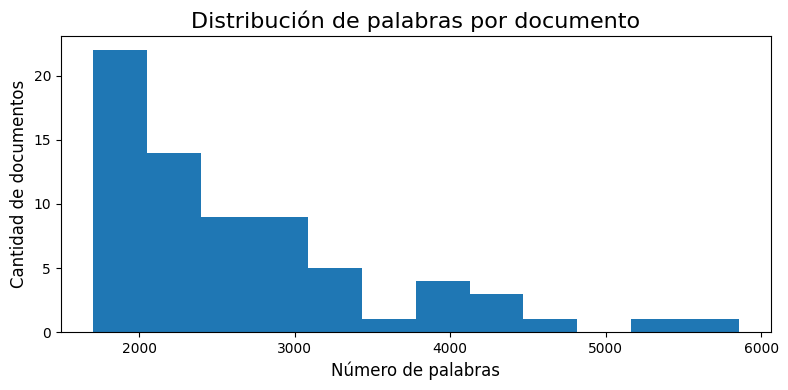

In [13]:
def tabla_resumen_distribucion(nombre, valores):
    return pd.DataFrame(
        [
            ["min", int(valores.min())],
            ["mediana", int(np.median(valores))],
            ["media", round(float(valores.mean()), 2)],
            ["max", int(valores.max())],
        ],
        columns=["estadistica", nombre],
    )


tabla_corpus = pd.DataFrame(
    [
        ["numero_documentos", len(corpus)],
        ["juego", "Counter-Strike"],
        ["reviews_por_documento", REVIEWS_PER_DOCUMENT],
        ["total_reviews_usadas", int(corpus["reviews_usadas"].sum())],
        ["palabras_totales", int(corpus["palabras"].sum())],
    ],
    columns=["estadistica", "corpus_counter_strike"],
)

tabla_palabras_por_doc = tabla_resumen_distribucion(
    "palabras_por_documento",
    corpus["palabras"]
)

display(tabla_corpus)
display(tabla_palabras_por_doc)


plt.figure(figsize=(8, 4))
plt.hist(corpus["palabras"], bins=12)
plt.title("Distribución de palabras por documento", fontsize=16)
plt.xlabel("Número de palabras", fontsize=12)
plt.ylabel("Cantidad de documentos", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

El corpus final tiene 70 documentos, cada uno construido a partir de 80 reseñas de Counter-Strike. Aunque todos los documentos usan la misma cantidad de reviews, no todos tienen la misma longitud: algunos bloques tienen cerca de 1700 palabras, mientras que el más largo supera las 5800. Esto ocurre porque algunas reseñas son mucho más extensas que otras.

La mayoría de los documentos se concentra entre 1700 y 3000 palabras, por lo que el corpus queda relativamente balanceado, aunque existen algunos bloques más largos que podrían tener mayor peso en una matriz basada en conteos. Por esta razón, más adelante será conveniente usar TF-IDF, ya que ayuda a reducir el efecto de las diferencias de longitud y de las palabras demasiado frecuentes.

## P2. Hipótesis inicial

Esperamos que aparezcan componentes relacionadas con mecánicas propias de Counter-Strike, como equipos, terroristas, antiterroristas, mapas, rondas y objetivos. Además, esperamos encontrar temas asociados a nostalgia, recuerdos de infancia, experiencia competitiva y comparación con otras versiones de la franquicia, como Counter-Strike: Global Offensive.

## P3. Preprocesamiento del texto

### P3.1 Primera versión: conteo de términos sin limpieza

Partimos con una representación simple del corpus: cada documento se transforma en un vector de conteos de palabras. En esta primera versión no usamos TF-IDF, lematización ni una limpieza avanzada. La idea es obtener una primera matriz textual y observar qué problemas aparecen cuando el análisis se basa solamente en frecuencias crudas.

In [14]:
vectorizer_raw = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=1,
)

X_raw = vectorizer_raw.fit_transform(corpus["texto"])
vocabulario_raw = vectorizer_raw.get_feature_names_out()

A_raw = X_raw.toarray().T

print("Forma de X_raw (documentos x terminos):", X_raw.shape)
print("Forma de A_raw (terminos x documentos):", A_raw.shape)
print("Primeros terminos del vocabulario:", vocabulario_raw[:30])

Forma de X_raw (documentos x terminos): (70, 8760)
Forma de A_raw (terminos x documentos): (8760, 70)
Primeros terminos del vocabulario: ['aaa' 'aaaaaaaaand' 'aaaaaawesome' 'aaaaah' 'aaaah' 'aaah' 'abandonated'
 'abandoned' 'abbreviated' 'abd' 'abderahmane' 'abilities' 'ability'
 'abit' 'able' 'abo' 'abou' 'about' 'aboutteuo' 'above' 'absent'
 'abslutly' 'abso' 'absoltely' 'absoludly' 'absolute' 'absolutely'
 'absolutly' 'absorb' 'abstracted']


,estadistica,corpus_sin_limpieza
0,numero_documentos,70
1,numero_terminos,8760
2,forma_X_documentos_x_terminos,70 x 8760
3,forma_A_terminos_x_documentos,8760 x 70
4,entradas_no_cero,46969
5,densidad,0.0766
6,sparsity,0.9234


,estadistica,corpus_sin_limpieza
0,min,1282.00
1,mediana,1773.00
2,media,1993.39
3,max,4492.00


,estadistica,corpus_sin_limpieza
0,min,386.00
1,mediana,616.00
2,media,670.99
3,max,1324.00


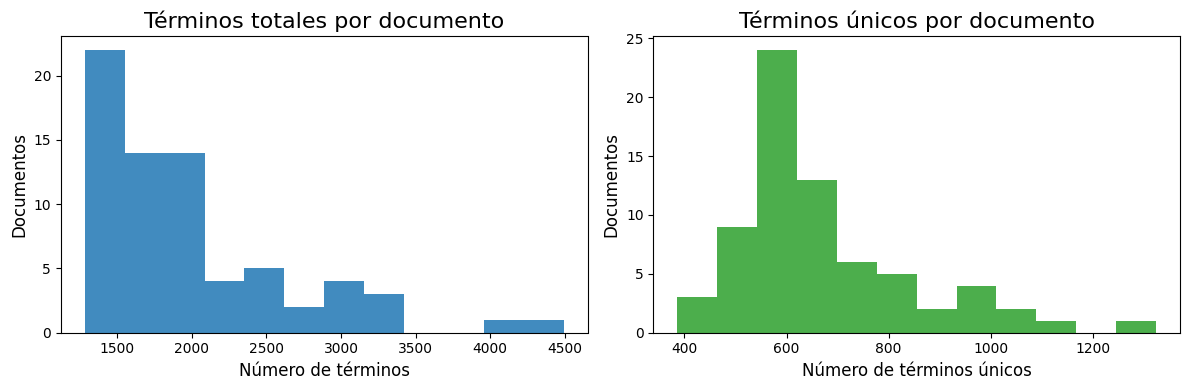

In [15]:
def resumen_vectorizacion(nombre, X, A, vocabulario):
    conteos_por_doc = np.asarray(X.sum(axis=1)).ravel()
    terminos_unicos_por_doc = np.asarray((X > 0).sum(axis=1)).ravel()

    total_celdas = X.shape[0] * X.shape[1]
    densidad = X.nnz / total_celdas

    tabla_corpus = pd.DataFrame(
        [
            ["numero_documentos", X.shape[0]],
            ["numero_terminos", X.shape[1]],
            ["forma_X_documentos_x_terminos", f"{X.shape[0]} x {X.shape[1]}"],
            ["forma_A_terminos_x_documentos", f"{A.shape[0]} x {A.shape[1]}"],
            ["entradas_no_cero", X.nnz],
            ["densidad", round(float(densidad), 4)],
            ["sparsity", round(float(1 - densidad), 4)],
        ],
        columns=["estadistica", nombre],
    )

    tabla_terminos_por_doc = tabla_resumen_distribucion(nombre, conteos_por_doc)
    tabla_terminos_unicos_por_doc = tabla_resumen_distribucion(nombre, terminos_unicos_por_doc)

    return (
        tabla_corpus,
        tabla_terminos_por_doc,
        tabla_terminos_unicos_por_doc,
        conteos_por_doc,
        terminos_unicos_por_doc,
    )


(
    tabla_corpus_raw,
    tabla_terminos_por_doc_raw,
    tabla_terminos_unicos_por_doc_raw,
    conteos_doc_raw,
    terminos_unicos_doc_raw,
) = resumen_vectorizacion(
    "corpus_sin_limpieza",
    X_raw,
    A_raw,
    vocabulario_raw,
)

display(tabla_corpus_raw)
display(tabla_terminos_por_doc_raw)
display(tabla_terminos_unicos_por_doc_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conteos_doc_raw, bins=12, color="tab:blue", alpha=0.85)
axes[0].set_title("Términos totales por documento", fontsize=16)
axes[0].set_xlabel("Número de términos", fontsize=12)
axes[0].set_ylabel("Documentos", fontsize=12)
axes[0].grid(False)

axes[1].hist(terminos_unicos_doc_raw, bins=12, color="tab:green", alpha=0.85)
axes[1].set_title("Términos únicos por documento", fontsize=16)
axes[1].set_xlabel("Número de términos únicos", fontsize=12)
axes[1].set_ylabel("Documentos", fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

La primera matriz textual tiene 70 documentos y 8792 términos distintos. La matriz X tiene documentos en las filas y términos en las columnas, mientras que A corresponde a su transpuesta.

La matriz es bastante dispersa, su densidad es 0.0766, es decir, solo una pequeña parte de sus entradas es distinta de cero.

También se observa que los documentos no tienen exactamente la misma cantidad de términos. Aunque todos fueron construidos con 80 reseñas, algunos bloques contienen muchas más palabras que otros.

### P3.2 Palabras dominantes antes de limpiar

Antes de aplicar SVD, revisamos cuáles son los términos más frecuentes en la matriz cruda. Esto permite identificar si la representación está dominada por palabras informativas sobre el contenido del juego o por palabras demasiado generales.

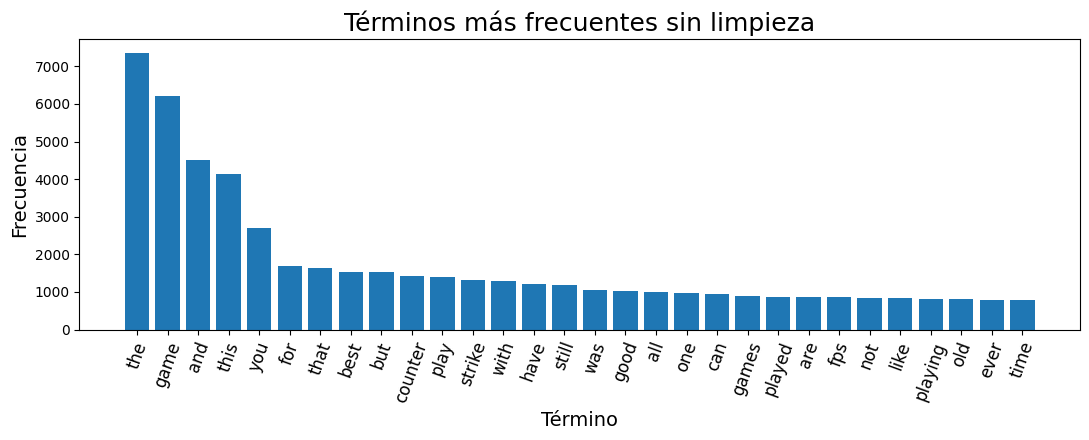

Top 30 términos más frecuentes sin limpieza:


array(['the', 'game', 'and', 'this', 'you', 'for', 'that', 'best', 'but',
       'counter', 'play', 'strike', 'with', 'have', 'still', 'was',
       'good', 'all', 'one', 'can', 'games', 'played', 'are', 'fps',
       'not', 'like', 'playing', 'old', 'ever', 'time'], dtype=object)

In [16]:
frecuencias_raw = np.asarray(X_raw.sum(axis=0)).ravel()
indices_frecuentes_raw = np.argsort(frecuencias_raw)[::-1][:30]
terminos_frecuentes_raw = vocabulario_raw[indices_frecuentes_raw]
conteos_frecuentes_raw = frecuencias_raw[indices_frecuentes_raw]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(terminos_frecuentes_raw, conteos_frecuentes_raw)
ax.set_title("Términos más frecuentes sin limpieza", fontsize=18)
ax.set_xlabel("Término", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=12)
plt.tight_layout()
plt.show()

print("Top 30 términos más frecuentes sin limpieza:")
terminos_frecuentes_raw

En la matriz cruda, los términos más frecuentes son principalmente palabras generales del inglés, como "the", "and", "this", "you", "for" y "that". Estas palabras aparecen muchas veces, pero no ayudan demasiado a distinguir temas dentro de las reseñas.

También aparecen términos más relacionados con el corpus, como "game", "counter", "strike", "play", "fps", "played" y "games". Sin embargo, en esta primera versión todavía están mezclados con muchas palabras funcionales. Esto muestra una limitación de usar conteos crudos sin limpieza, las componentes principales de la SVD podrían capturar frecuencia general del lenguaje o longitud de los documentos, en vez de temas más interpretables sobre Counter-Strike.

## P4. Construcción de la matriz textual

A partir del preprocesamiento definido en el punto anterior, construimos la matriz textual que será analizada con SVD. Usamos "TfidfVectorizer", eliminando stopwords en inglés, descartando términos muy raros o demasiado frecuentes, e incluyendo unigramas y bigramas.

El vectorizador entrega una matriz X con documentos en las filas y términos en las columnas. Para seguir la convención del curso, usamos la matriz transpuesta


### P4.1 Construcción de la matriz TF-IDF

In [17]:
stopwords_ingles = text.ENGLISH_STOP_WORDS

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stopwords_ingles),
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
)

X = vectorizer.fit_transform(corpus["texto"])
vocabulario = vectorizer.get_feature_names_out()

A = X.toarray().T

print("Forma de X (documentos x terminos):", X.shape)
print("Forma de A (terminos x documentos):", A.shape)
print("Primeros terminos del vocabulario:", vocabulario[:30])

Forma de X (documentos x terminos): (70, 11041)
Forma de A (terminos x documentos): (11041, 70)
Primeros terminos del vocabulario: ['aaa' 'abandoned' 'ability' 'abit' 'able' 'able hit' 'able play'
 'able run' 'absolute' 'absolute classic' 'absolutely'
 'absolutely amazing' 'absolutely best' 'absolutely love'
 'absolutely play' 'absolutly' 'absorb' 'absorb bullet' 'acc' 'accept'
 'accepted' 'access' 'accessibility' 'accessible' 'accessible easy'
 'accessories' 'accident' 'accidently' 'acclaimed' 'acclaimed half']


La matriz X tiene dimensión 70 x 11041, es decir, 70 documentos y 11041 términos. Como el curso usa la convención término-documento, definimos A = X^T, por lo que la matriz final tiene dimensión 11041 x 70.

En esta matriz, las filas representan términos y las columnas representan documentos.

### P4.2 Resumen de la matriz final

In [18]:
(
    tabla_corpus_tfidf,
    tabla_terminos_por_doc_tfidf,
    tabla_terminos_unicos_por_doc_tfidf,
    pesos_doc_tfidf,
    terminos_unicos_doc_tfidf,
) = resumen_vectorizacion(
    "corpus_tfidf",
    X,
    A,
    vocabulario,
)

display(tabla_corpus_tfidf)
display(tabla_terminos_unicos_por_doc_tfidf)

,estadistica,corpus_tfidf
0,numero_documentos,70
1,numero_terminos,11041
2,forma_X_documentos_x_terminos,70 x 11041
3,forma_A_terminos_x_documentos,11041 x 70
4,entradas_no_cero,59394
5,densidad,0.0768
6,sparsity,0.9232


,estadistica,corpus_tfidf
0,min,471.00
1,mediana,770.00
2,media,848.49
3,max,1977.00


### P4.3 Comparación con la matriz de conteos crudos

In [19]:
comparacion_vectorizaciones = pd.DataFrame(
    [
        ["conteos_crudos", X_raw.shape[0], X_raw.shape[1], X_raw.nnz, round(X_raw.nnz / (X_raw.shape[0] * X_raw.shape[1]), 4)],
        ["tfidf_limpio", X.shape[0], X.shape[1], X.nnz, round(X.nnz / (X.shape[0] * X.shape[1]), 4)],
    ],
    columns=["version", "documentos", "terminos", "entradas_no_cero", "densidad"]
)

display(comparacion_vectorizaciones)

,version,documentos,terminos,entradas_no_cero,densidad
0,conteos_crudos,70,8760,46969,0.0766
1,tfidf_limpio,70,11041,59394,0.0768


La matriz TF-IDF conserva los mismos 70 documentos, pero aumenta el vocabulario respecto de la versión con conteos crudos porque incluye unigramas y bigramas. La densidad se mantiene baja, lo cual es normal en datos de texto, ya que cada documento utiliza solo una parte del vocabulario total.

Esta matriz A será la entrada para la descomposición en valores singulares del siguiente punto.

## P5. Cálculo de la SVD

Aplicamos la descomposición en valores singulares a la matriz A, construida a partir de TF-IDF. Esta matriz sigue la convención del curso: las filas representan términos y las columnas representan documentos.

La descomposición tiene la forma

A=UΣVT

En este contexto, las columnas de U representan direcciones principales en el espacio de términos, mientras que las columnas de V representan direcciones principales en el espacio de documentos. Los valores singulares indican cuánta información o estructura captura cada componente.

In [20]:
U, s, VT = np.linalg.svd(A, full_matrices=False)

print("Forma de A:", A.shape)
print("Forma de U:", U.shape)
print("Forma de s:", s.shape)
print("Forma de VT:", VT.shape)

print("Primeros 10 valores singulares:")
print(np.round(s[:10], 4))

A_reconstruida = U @ np.diag(s) @ VT

error_reconstruccion = np.linalg.norm(A - A_reconstruida)
error_relativo = error_reconstruccion / np.linalg.norm(A)

print("Error de reconstruccion:", error_reconstruccion)
print("Error relativo:", error_relativo)

Forma de A: (11041, 70)
Forma de U: (11041, 70)
Forma de s: (70,)
Forma de VT: (70, 70)
Primeros 10 valores singulares:
[3.1486 1.3911 1.3279 1.2815 1.1903 1.101  1.059  1.0323 1.0232 1.0206]
Error de reconstruccion: 2.226674859686824e-14
Error relativo: 2.661385495983343e-15


**Interpretación.** La matriz A tiene dimensión 11041 x 70, es decir, 11041 términos y 70 documentos. Al calcular la SVD con "full_matrices=False", obtenemos U de tamaño 11041 x 70, un vector "s" con 70 valores singulares y V^T de tamaño 70 x 70.

El error relativo de reconstrucción es del orden de 10^(-15), por lo que la descomposición reconstruye correctamente la matriz original. Esto confirma que la SVD fue calculada de forma consistente.

Los primeros valores singulares son los más grandes, por lo que las primeras componentes concentran más estructura del corpus. En las siguientes secciones analizaremos su decaimiento para elegir una dimensión reducida k.

## P6. Valores singulares y elección de dimensión

Los valores singulares indican cuánta estructura captura cada componente de la SVD. Si los primeros valores singulares son mucho más grandes que el resto, eso sugiere que una representación de baja dimensión puede conservar parte importante de la información del corpus.

Para estudiar esto, graficamos los valores singulares y la proporción acumulada de energía explicada.

In [21]:
energia = s**2
energia_acumulada = np.cumsum(energia) / np.sum(energia)

tabla_valores_singulares = pd.DataFrame({
    "componente": np.arange(1, len(s) + 1),
    "valor_singular": s,
    "energia_acumulada": energia_acumulada,
})

display(tabla_valores_singulares.head(15))

,componente,valor_singular,energia_acumulada
0,1,3.148579,0.141622
1,2,1.391069,0.169266
2,3,1.327867,0.194455
3,4,1.281463,0.217914
4,5,1.190267,0.238153
5,6,1.100983,0.255470
6,7,1.059010,0.271491
7,8,1.032265,0.286714
8,9,1.023220,0.301671
9,10,1.020587,0.316551


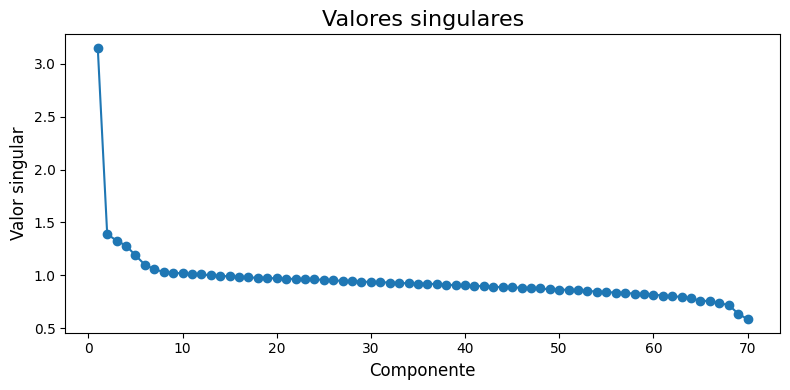

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.title("Valores singulares", fontsize=16)
plt.xlabel("Componente", fontsize=12)
plt.ylabel("Valor singular", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

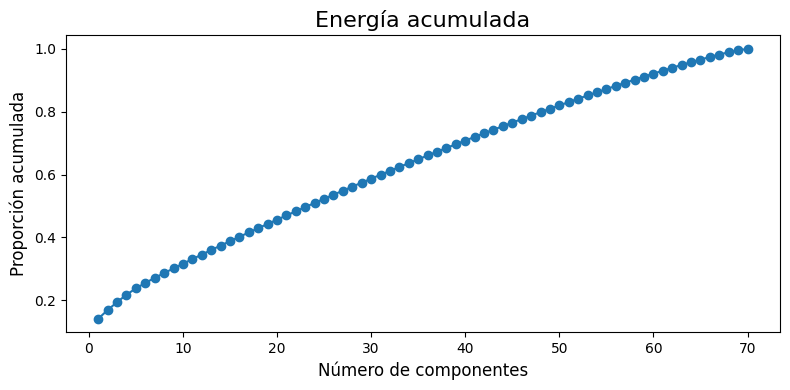

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(s) + 1), energia_acumulada, marker="o")
plt.title("Energía acumulada", fontsize=16)
plt.xlabel("Número de componentes", fontsize=12)
plt.ylabel("Proporción acumulada", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

In [24]:
for umbral in [0.5, 0.6, 0.7, 0.8, 0.9]:
    k_umbral = np.searchsorted(energia_acumulada, umbral) + 1
    print(f"Componentes para alcanzar {umbral:.0%} de energía:", k_umbral)

Componentes para alcanzar 50% de energía: 24
Componentes para alcanzar 60% de energía: 32
Componentes para alcanzar 70% de energía: 40
Componentes para alcanzar 80% de energía: 49
Componentes para alcanzar 90% de energía: 58


El gráfico de valores singulares muestra que la primera componente es claramente dominante, su valor singular es mucho mayor que el resto. Esto sugiere que existe una dirección principal fuerte en el corpus, probablemente asociada a vocabulario general muy común en las reseñas de Counter-Strike.

Después de las primeras componentes, los valores singulares disminuyen de forma más gradual.

Para alcanzar el 50% de energía se necesitan 24 componentes, para el 70% se necesitan 40 y para el 90% se necesitan 58. Por lo tanto, una representación muy pequeña pierde bastante información, pero sigue siendo útil para visualizar patrones generales.

Para las visualizaciones en dos dimensiones usaremos principalmente las componentes 1 y 2, porque son las de mayor valor singular. Sin embargo, para la representación reducida del corpus elegimos k = 40, ya que conserva aproximadamente el 70% de la energía total y ofrece un equilibrio razonable entre reducción de dimensión e información conservada.

In [25]:
k = 40

resumen_k = pd.DataFrame(
    [
        ["k_elegido", k],
        ["energia_acumulada", round(float(energia_acumulada[k - 1]), 4)],
        ["criterio", "aproximadamente 70% de energia"],
    ],
    columns=["elemento", "valor"]
)

display(resumen_k)

,elemento,valor
0,k_elegido,40
1,energia_acumulada,0.7082
2,criterio,aproximadamente 70% de energia


## P7. Representación de documentos y términos en baja dimensión

### P7.1 Representación 2D de documentos

Usamos las dos primeras componentes de la SVD para construir una representación bidimensional de los documentos.

In [26]:
D2 = np.diag(s[:2]) @ VT[:2, :]

docs_2d = pd.DataFrame({
    "documento": corpus["documento"],
    "x": D2[0, :],
    "y": D2[1, :],
    "palabras": corpus["palabras"],
    "reviews_usadas": corpus["reviews_usadas"],
})

display(docs_2d.head())

,documento,x,y,palabras,reviews_usadas
0,bloque_001,-0.546496,0.072780,5854,80
1,bloque_002,-0.474194,-0.133274,5290,80
2,bloque_003,-0.449766,0.269576,3293,80
3,bloque_004,-0.405913,-0.070691,2957,80
4,bloque_005,-0.439274,-0.192346,3134,80


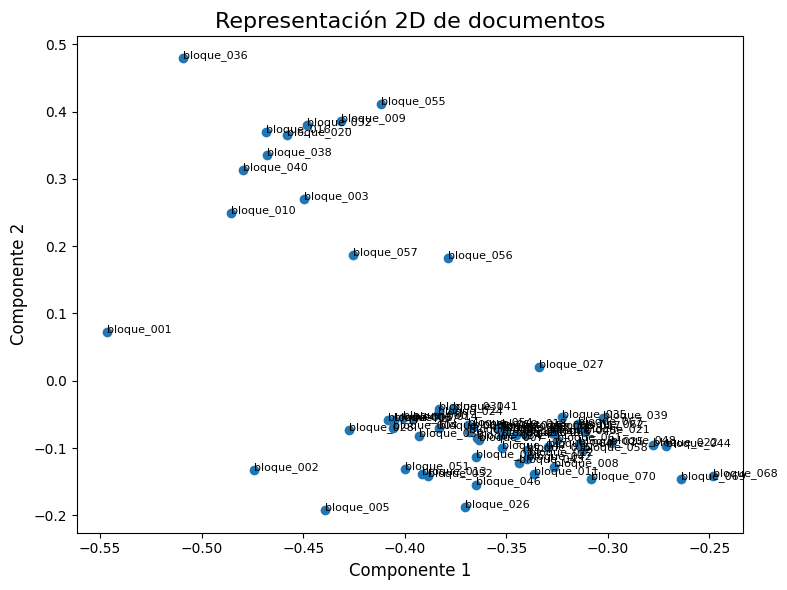

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(docs_2d["x"], docs_2d["y"])

for _, fila in docs_2d.iterrows():
    plt.text(fila["x"], fila["y"], fila["documento"], fontsize=8)

plt.title("Representación 2D de documentos", fontsize=16)
plt.xlabel("Componente 1", fontsize=12)
plt.ylabel("Componente 2", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

En la representación 2D de documentos, cada punto corresponde a un bloque de 80 reseñas de Counter-Strike. Se observa que la mayoría de los documentos queda agrupada en una zona relativamente compacta, especialmente entre valores cercanos en la componente 1 y componente 2. Esto sugiere que muchos bloques comparten vocabulario parecido, lo cual es esperable porque todos pertenecen al mismo videojuego.

También aparecen algunos documentos más alejados, como "bloque_001", "bloque_036" y "bloque_055". Estos bloques podrían contener reseñas con vocabulario más particular, por ejemplo opiniones más extensas, menciones a aspectos específicos del juego, nostalgia, críticas técnicas o comparaciones con otros juegos.


### P7.2 Representación 2D de términos

Además de representar documentos, la SVD permite representar términos en baja dimensión.


In [28]:
T2 = U[:, :2] @ np.diag(s[:2])

terminos_2d = pd.DataFrame({
    "termino": vocabulario,
    "x": T2[:, 0],
    "y": T2[:, 1],
})

terminos_2d["norma"] = np.sqrt(
    terminos_2d["x"]**2 + terminos_2d["y"]**2
)

terminos_destacados = terminos_2d.sort_values(
    "norma",
    ascending=False
).head(40)

display(terminos_destacados.head(20))

,termino,x,y,norma
9761,team,-0.382899,-0.042009,0.385196
10665,way,-0.254338,0.112698,0.278188
9848,terrorist,-0.267845,0.067960,0.276332
6033,maps,-0.257307,-0.002732,0.257321
10496,version,-0.211236,-0.040776,0.215136
2229,dont,-0.211265,-0.020592,0.212266
6272,mod,-0.204804,-0.025361,0.206369
6327,mods,-0.186181,0.074391,0.200493
8189,remember,-0.188471,0.064202,0.199106
4062,global,-0.199089,-0.002078,0.199100


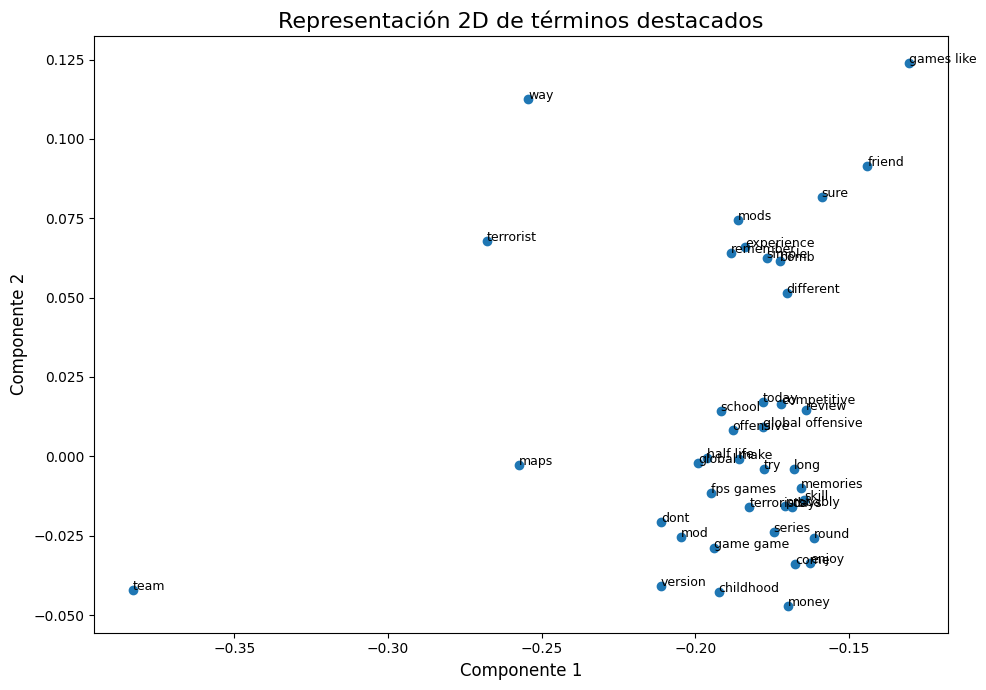

In [29]:
plt.figure(figsize=(10, 7))
plt.scatter(terminos_destacados["x"], terminos_destacados["y"])

for _, fila in terminos_destacados.iterrows():
    plt.text(fila["x"], fila["y"], fila["termino"], fontsize=9)

plt.title("Representación 2D de términos destacados", fontsize=16)
plt.xlabel("Componente 1", fontsize=12)
plt.ylabel("Componente 2", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

En la representación 2D de términos destacados aparecen varias palabras directamente relacionadas con Counter-Strike, como "terrorist", "terrorists", "bomb", "team", "maps", y "fps games". Esto muestra que la SVD está capturando vocabulario propio del juego y de su género.

También aparecen términos asociados a experiencia personal o nostalgia, como "childhood", "remember", "school", "experience", "friend" y "memories". Esto es coherente con el corpus, ya que muchas reseñas de juegos antiguos en Steam no solo describen la mecánica del juego, sino también recuerdos personales de quienes lo jugaron durante años.

Algunos términos como "half life" y "mods" sugieren una componente histórica del juego, relacionada con el origen de Counter-Strike como mod de Half-Life. Por otro lado, palabras como "global", "offensive" y "version" pueden reflejar comparaciones con otras versiones de la franquicia.

En conjunto, la visualización sugiere que las primeras componentes no solo capturan términos técnicos del juego, sino también dimensiones semánticas relacionadas con nostalgia, experiencia de juego y comparación entre versiones.

## P8. Exploración semántica

### P8.1 Interpretación de componentes

Para entender mejor qué representa cada componente de la SVD, revisamos los términos con mayor peso positivo y negativo en las columnas de U. Como U describe direcciones en el espacio de términos, los términos con pesos extremos ayudan a interpretar posibles temas latentes del corpus.

In [30]:
def terminos_importantes_componente(U, s, vocabulario, componente, n=20):
    pesos = U[:, componente] * s[componente]

    idx = np.argsort(np.abs(pesos))[-n:][::-1]

    tabla = pd.DataFrame({
        "termino": vocabulario[idx],
        "peso": pesos[idx],
        "peso_absoluto": np.abs(pesos[idx]),
        "componente": componente + 1,
    })

    return tabla


for comp in [0, 1, 2, 3]:
    print(f"Componente {comp + 1}")
    display(terminos_importantes_componente(U, s, vocabulario, comp, n=20))

Componente 1


,termino,peso,peso_absoluto,componente
0,team,-0.382899,0.382899,1
1,terrorist,-0.267845,0.267845,1
2,maps,-0.257307,0.257307,1
3,way,-0.254338,0.254338,1
4,dont,-0.211265,0.211265,1
5,version,-0.211236,0.211236,1
6,mod,-0.204804,0.204804,1
7,global,-0.199089,0.199089,1
8,half life,-0.196285,0.196285,1
9,fps games,-0.194878,0.194878,1


Componente 2


,termino,peso,peso_absoluto,componente
0,games like,0.123921,0.123921,2
1,friend house,0.122861,0.122861,2
2,competitively,0.119776,0.119776,2
3,way,0.112698,0.112698,2
4,saw,0.110059,0.110059,2
5,house,0.108870,0.108870,2
6,award,-0.105850,0.105850,2
7,wouldn,0.101774,0.101774,2
8,ofcourse,0.101671,0.101671,2
9,people played,0.096462,0.096462,2


Componente 3


,termino,peso,peso_absoluto,componente
0,interface,0.136997,0.136997,3
1,retail,0.121971,0.121971,3
2,team,0.112297,0.112297,3
3,terrorist,0.109080,0.109080,3
4,retail package,0.101967,0.101967,3
5,sound,0.100244,0.100244,3
6,user,0.088198,0.088198,3
7,feature,0.087459,0.087459,3
8,package,0.085817,0.085817,3
9,getting,0.084988,0.084988,3


Componente 4


,termino,peso,peso_absoluto,componente
0,terrorist,0.221343,0.221343,4
1,success,0.186002,0.186002,4
2,team,0.175167,0.175167,4
3,affects,0.172740,0.172740,4
4,team success,0.172740,0.172740,4
5,role,0.166564,0.166564,4
6,rescue,0.137553,0.137553,4
7,round,0.118769,0.118769,4
8,based game,0.115759,0.115759,4
9,enemy,0.097715,0.097715,4


Las primeras componentes muestran distintos grupos de vocabulario dentro de las reseñas de Counter-Strike.

La componente 1 parece capturar vocabulario general del juego y de su historia. Aparecen términos como "team", "terrorist", "maps", "mod", "half life", "global", "offensive", "childhood" y "remember". Esto sugiere que esta componente mezcla elementos propios de la jugabilidad con referencias históricas y nostálgicas sobre Counter-Strike.

La componente 2 está más relacionada con experiencia personal y recuerdos de los jugadores. Términos como "friend house", "games like", "saw", "house", "friend", "happy" y "people played" sugieren reseñas donde los usuarios narran experiencias pasadas o recuerdos asociados al juego.

La componente 3 parece asociarse con aspectos técnicos o descriptivos del juego. Aparecen términos como "interface", "retail", "sound", "feature", "user interface", "sound footsteps", "bullet" y "realistic". Esta componente podría estar capturando reseñas que describen características concretas del juego, su interfaz, sonido, etc.

La componente 4 se relaciona más directamente con la mecánica del juego por equipos. Términos como "terrorist", "team", "team success", "role", "rescue", "round", "enemy" y "counter terrorist" apuntan a elementos centrales de Counter-Strike, roles, rondas, enemigos, objetivos y cooperación de equipo.

### P8.2 Exploración semántica: documentos cercanos

Usamos la representación reducida con k = 40 componentes para buscar documentos cercanos entre sí. Dos documentos cercanos en este espacio tienen patrones de vocabulario similares según la SVD.

Como cada documento corresponde a un bloque de 80 reseñas, esta comparación permite identificar grupos de reseñas que tratan temas parecidos.

In [31]:
Dk = np.diag(s[:k]) @ VT[:k, :]
documentos_k = Dk.T

similitud_docs = cosine_similarity(documentos_k)

pares = []

for i in range(similitud_docs.shape[0]):
    for j in range(i + 1, similitud_docs.shape[1]):
        pares.append({
            "documento_1": corpus.loc[i, "documento"],
            "documento_2": corpus.loc[j, "documento"],
            "similitud_coseno": similitud_docs[i, j],
            "palabras_doc_1": corpus.loc[i, "palabras"],
            "palabras_doc_2": corpus.loc[j, "palabras"],
        })

pares_cercanos = pd.DataFrame(pares).sort_values(
    "similitud_coseno",
    ascending=False
).reset_index(drop=True)

display(pares_cercanos.head(10))

,documento_1,documento_2,similitud_coseno,palabras_doc_1,palabras_doc_2
0,bloque_056,bloque_057,0.980543,3070,3665
1,bloque_020,bloque_057,0.958838,4365,3665
2,bloque_020,bloque_056,0.944733,4365,3070
3,bloque_002,bloque_026,0.918514,5290,2380
4,bloque_009,bloque_036,0.905542,2825,4176
5,bloque_016,bloque_036,0.904434,2890,4176
6,bloque_036,bloque_040,0.881109,4176,4655
7,bloque_005,bloque_026,0.878178,3134,2380
8,bloque_022,bloque_023,0.854077,2052,3277
9,bloque_032,bloque_036,0.850907,2717,4176


In [32]:
def mostrar_resumen_documento(nombre_documento, n_caracteres=700):
    fila = corpus[corpus["documento"] == nombre_documento].iloc[0]
    print("Documento:", fila["documento"])
    print("Reviews usadas:", fila["reviews_usadas"])
    print("Palabras:", fila["palabras"])
    print()
    print(fila["texto"][:n_caracteres])
    print("-" * 80)


doc1 = pares_cercanos.loc[0, "documento_1"]
doc2 = pares_cercanos.loc[0, "documento_2"]

mostrar_resumen_documento(doc1)
mostrar_resumen_documento(doc2)

Documento: bloque_056
Reviews usadas: 80
Palabras: 3070

My childhood is here ALL of it &lt;3 Having only played CSGO for the past year or so, it is really nice to see what that game was rooted off of. I now know playing 1.6 what all the hype about Counter Strike is and the history behind it. 1.6 for it's time period was such a benchmark game. Really awesome! Counter Strike one of the best series of games.This is the best part of the series.This isn't the game which has high graphics or is realistic but to be honest it is very addicting. No negative reviews about the game...Just amazing. 'Recommended'. i think this game is one of the best games what ever coded in the written history This game is very old,but it is still one of the most enjoyable a
--------------------------------------------------------------------------------
Documento: bloque_057
Reviews usadas: 80
Palabras: 3665

what better way to play an fps than the original? this game paved the way for all modern day fps with ou

Los documentos más cercanos en la representación reducida son "bloque_056" y "bloque_057", con una similitud coseno de 0.9811. Esto indica que ambos bloques tienen vocabulario muy parecido según las primeras 40 componentes de la SVD.

Al revisar el contenido de ambos documentos, se observa que las reseñas comparten una temática clara: nostalgia, historia del juego y valoración positiva de Counter-Strike como un clásico. En "bloque_056" aparecen frases asociadas a infancia, trayectoria del juego y comparación con CS:GO. En "bloque_057" también se repiten ideas como haber jugado desde la niñez, considerar el juego como el origen de los FPS modernos y mantener una valoración afectiva del juego.

Esto muestra que la representación reducida no solo agrupa documentos por palabras exactas, sino también por temas latentes. En este caso, la SVD identifica una cercanía semántica entre bloques de reseñas centrados en memoria personal, nostalgia y reconocimiento histórico del juego.

### P8.3 Exploración semántica: términos cercanos

Además de comparar documentos, usamos la representación reducida para buscar términos cercanos entre sí. Dos términos cercanos en este espacio aparecen en contextos similares dentro del corpus.

Para esto usamos k = 40 componentes y calculamos similitud coseno entre las representaciones reducidas de los términos.

In [33]:
Tk = U[:, :k] @ np.diag(s[:k])

terminos_k = pd.DataFrame(
    Tk,
    index=vocabulario
)

def terminos_cercanos(termino, n=10):
    if termino not in terminos_k.index:
        print(f"El termino '{termino}' no esta en el vocabulario.")
        return None

    vector = terminos_k.loc[[termino]].values
    sims = cosine_similarity(vector, terminos_k.values).ravel()

    tabla = pd.DataFrame({
        "termino": terminos_k.index,
        "similitud_coseno": sims,
    })

    tabla = tabla[tabla["termino"] != termino]

    return tabla.sort_values(
        "similitud_coseno",
        ascending=False
    ).head(n)

for termino in ["team", "terrorist", "maps", "childhood", "global offensive"]:
    print("Términos cercanos a:", termino)
    display(terminos_cercanos(termino, n=10))

Términos cercanos a: team


,termino,similitud_coseno
524,based,0.840770
4801,hostages,0.830799
1478,complete,0.813785
10694,weapons,0.813123
9764,team based,0.812498
8241,rescue,0.790985
7623,popular,0.787656
9848,terrorist,0.780771
5296,killing,0.775055
9795,teammates,0.774815


Términos cercanos a: terrorist


,termino,similitud_coseno
1636,counter terrorist,0.973480
10302,type,0.874348
8241,rescue,0.851766
7176,planting,0.840095
4801,hostages,0.823220
8478,save,0.816337
4798,hostage,0.807851
8382,round,0.805950
9850,terrorist counter,0.803579
7177,planting bomb,0.797884


Términos cercanos a: maps


,termino,similitud_coseno
10262,try,0.811521
6327,mods,0.790601
34,account,0.773142
1449,competitive,0.762748
10665,way,0.761246
2937,fps games,0.757642
5971,make,0.755320
524,based,0.754646
1478,complete,0.753497
5275,kill,0.753214


Términos cercanos a: childhood


,termino,similitud_coseno
1173,childhood game,0.806171
6162,memories,0.800792
10911,year,0.771064
8545,school,0.752797
3254,game childhood,0.749337
1343,come,0.745275
3370,game game,0.742984
750,big,0.734776
4727,history,0.731471
1845,days,0.730971


Términos cercanos a: global offensive


,termino,similitud_coseno
6680,offensive,0.993746
4062,global,0.972903
9504,strike global,0.868116
10665,way,0.802246
8908,simple,0.768219
853,bought,0.760104
8326,right,0.759634
4007,gets,0.759445
1845,days,0.749724
1430,compared,0.749299


La búsqueda de términos cercanos muestra relaciones coherentes dentro del corpus. El término "team" aparece cerca de "hostages", "weapons", "team based", "rescue", "terrorist", "enemy" y "teammates", lo que refleja la dimensión cooperativa y competitiva de Counter-Strike.

El término "terrorist" aparece muy cerca de "counter terrorist", "rescue", "planting", "hostages", "round" y "planting bomb". Estos conceptos forman parte de las mecánicas centrales del juego.

El término "maps" aparece cercano a "mods", "kill", "tactical", "video" y "game like". Esto sugiere una asociación entre mapas, modificaciones y formas de jugar.

El término "childhood" aparece cercano a "memories", "childhood game", "school" y "game childhood". Esto muestra una dimensión nostálgica dentro de las reseñas.

Finalmente, "global offensive" aparece cerca de "offensive", "global", "strike global", "compared" y "memories". Esto sugiere que algunas reseñas comparan Counter-Strike original con otras versiones de la franquicia, especialmente Counter-Strike: Global Offensive.


## P9. Discusión, limitaciones y conclusiones

En este proyecto aplicamos LSA con SVD a un corpus construido a partir de reseñas de Counter-Strike. Para cumplir con el requisito de tener múltiples documentos, agrupamos las reseñas en bloques de 80 reviews, de modo que cada bloque funcionara como un documento del corpus.

La hipótesis inicial era que las reseñas de Counter-Strike mostrarían temas asociados a mecánicas del juego, experiencia competitiva, nostalgia y comparación con otras versiones de la franquicia. Los resultados obtenidos apoyan esta hipótesis. En las componentes principales y en la exploración de términos cercanos aparecieron conceptos como "team", "terrorist", "counter terrorist", "hostages", "planting bomb", "maps", "mods", "childhood", "memories" y "global offensive".

La representación reducida también permitió encontrar documentos cercanos entre sí. Por ejemplo, los bloques "bloque_056" y "bloque_057" tuvieron una similitud coseno muy alta y ambos contenían reseñas asociadas a nostalgia, infancia y valoración histórica del juego. Esto muestra que la SVD no solo captura palabras individuales, sino también patrones temáticos dentro del corpus.

Sin embargo, el análisis tiene limitaciones. Como todos los documentos provienen del mismo juego, por lo que no se esperan separaciones tan marcadas como en un corpus con videojuegos de géneros distintos. Tambien, los documentos fueron construidos artificialmente agrupando reseñas consecutivas, por lo que cada bloque puede mezclar opiniones y temas diferentes. Y tambien, LSA es una técnica lineal basada en coocurrencias de palabras, por lo que no entiende ironía, contexto profundo ni significado semántico como lo haría una lectura humana.

A pesar de estas limitaciones, el método permitió descubrir estructuras interpretables dentro de las reseñas. En particular, se identificaron dimensiones relacionadas con mecánicas de juego, roles, mapas, nostalgia y comparación con otras versiones de Counter-Strike. Por lo tanto, LSA con SVD funcionó como una herramienta exploratoria útil para resumir y visualizar patrones latentes en el corpus.